## 1) Imports libraries
The dataset columns include policy identifiers, geography, vehicle features, and financial outcomes such as `TotalPremium` and `TotalClaims`. We load the raw pipe-separated file, prepare a policy-level view, then run the statistical tests.

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from data_loader import load_data
from preprocessing import prepare_policy_level_data, normalize_gender
from hypothesis_tests import (
    matched_segment,
    chi_square_claim_frequency_test,
    welch_ttest_numeric,
    build_result_row,
    decision_from_pvalue,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

## 2) Load and prepare the data

The task data contains fields such as `UnderwrittenCoverID`, `PolicyID`, `TransactionMonth`, `Province`, `PostalCode`, `VehicleType`, `TotalPremium`, and `TotalClaims`. We read the file with `sep='|'` and build a policy-level frame.

In [13]:

df_raw = load_data(
    "../data/MachineLearningRating_v3.csv"
)

df_raw = normalize_gender(df_raw)
print(df_raw.columns)


Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')


In [14]:
policy = prepare_policy_level_data(df_raw)

print("Raw rows:", len(df_raw))
print("Policy-level rows:", len(policy))
policy.head()

Raw rows: 1000098
Policy-level rows: 116532


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Claimed,Margin
0,1,16,1970-01-01 00:00:00.000041609,False,ZA,Individual,Mr,English,First National Bank,Current account,Not specified,Male,South Africa,Western Cape,7888,Cape Province (Cape Town),Cape Town,Mobility - Motor,60027366.0,Passenger Vehicle,2011.0,TOYOTA,COROLLA 1.3 IMPACT,4.0,1330.0,74.0,S/D,4.0,40360.0,NaN,Yes,No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,500000.0,Monthly,256.8893,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0,0.0,0,0.0
1,2,16,1970-01-01 00:00:00.000041913,False,ZA,Individual,Mr,English,First National Bank,Current account,Not specified,Male,South Africa,Western Cape,7888,Cape Province (Cape Town),Cape Town,Mobility - Motor,60027366.0,Passenger Vehicle,2011.0,TOYOTA,COROLLA 1.3 IMPACT,4.0,1330.0,74.0,S/D,4.0,40360.0,NaN,Yes,No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,7500.0,Monthly,5.7087,No excess,Emergency Charges,Emergency Charges,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0,0.0,0,0.0
2,3,16,1970-01-01 00:00:00.000041609,False,ZA,Individual,Mr,English,First National Bank,Current account,Not specified,Male,South Africa,Western Cape,7888,Cape Province (Cape Town),Cape Town,Mobility - Motor,60027366.0,Passenger Vehicle,2011.0,TOYOTA,COROLLA 1.3 IMPACT,4.0,1330.0,74.0,S/D,4.0,40360.0,NaN,Yes,No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,Monthly,3.8057,No excess,Keys and Alarms,Keys and Alarms,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0,0.0,0,0.0
3,4,16,1970-01-01 00:00:00.000041671,False,ZA,Individual,Mr,English,First National Bank,Current account,Not specified,Male,South Africa,Western Cape,7888,Cape Province (Cape Town),Cape Town,Mobility - Motor,60027366.0,Passenger Vehicle,2011.0,TOYOTA,COROLLA 1.3 IMPACT,4.0,1330.0,74.0,S/D,4.0,40360.0,NaN,Yes,No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,7500.0,Monthly,5.7087,No excess,Cleaning and Removal of Accident Debris,Cleaning and Removal of Accident Debris,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0,0.0,0,0.0
4,5,16,1970-01-01 00:00:00.000041579,False,ZA,Individual,Mr,English,First National Bank,Current account,Not specified,Male,South Africa,Western Cape,7888,Cape Province (Cape Town),Cape Town,Mobility - Motor,60027366.0,Passenger Vehicle,2011.0,TOYOTA,COROLLA 1.3 IMPACT,4.0,1330.0,74.0,S/D,4.0,40360.0,NaN,Yes,No,0.0,NaN,NaN,NaN,NaN,NaN,NaN,3500.0,Monthly,1.9029,No excess,Signage and Vehicle Wraps,Signage and Vehicle Wraps,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0,0.0,0,0.0


## 3) Derived metrics used in Task 3

- **Claimed**: whether a policy had at least one claim.
- **Margin**: `TotalPremium - TotalClaims`

These are the base variables for claim frequency, claim severity, and profit/margin testing.

In [15]:
# Quick snapshot
summary = pd.DataFrame({
    "Metric": [
        "Total premium",
        "Total claims",
        "Claim frequency",
        "Average claim severity (positive claims only)",
        "Average margin"
    ],
    "Value": [
        f"R {policy['TotalPremium'].sum():,.2f}",
        f"R {policy['TotalClaims'].sum():,.2f}",
        f"{policy['Claimed'].mean() * 100:.2f}%",
        f"R {policy.loc[policy['TotalClaims'] > 0, 'TotalClaims'].mean():,.2f}",
        f"R {policy['Margin'].mean():,.2f}"
    ]
})
summary

,Metric,Value
0,Total premium,"R 60,094,235.59"
1,Total claims,"R 63,838,145.42"
2,Claim frequency,2.17%
3,Average claim severity (positive claims only),"R 25,255.06"
4,Average margin,R -32.13


## 4) Hypothesis 1 — No risk differences across provinces

**KPI:** Claim Frequency  
**Test:** Chi-squared test of independence

We compare two major provinces to keep the analysis interpretable and to avoid unequal segment sizes. The code below selects the two largest provinces and then matches the sample on the most common vehicle and cover segment shared by both groups.

In [16]:
province_a, province_b = policy["Province"].value_counts().index[:2].tolist()

province_subset = matched_segment(
    policy,
    group_col="Province",
    group_a=province_a,
    group_b=province_b,
    match_cols=["VehicleType", "CoverType"]
)

province_result = chi_square_claim_frequency_test(
    province_subset,
    group_col="Province",
    group_a=province_a,
    group_b=province_b,
    kpi_col="Claimed"
)

province_summary = (
    province_subset.groupby("Province")
    .agg(
        policies=("UnderwrittenCoverID", "count"),
        claim_frequency=("Claimed", "mean"),
        avg_severity=("TotalClaims", lambda s: s[s > 0].mean()),
        avg_margin=("Margin", "mean")
    )
    .reset_index()
)

province_summary

,Province,policies,claim_frequency,avg_severity,avg_margin
0,Gauteng,4682,0.118753,45035.058253,-2445.126597
1,KwaZulu-Natal,2272,0.112236,46765.537894,-1812.170589


In [17]:
province_result

{'test': 'chi-squared',
 'chi2': np.float64(0.5689042581816607),
 'p_value': np.float64(0.4506946637854512),
 'dof': 1,
 'contingency': Claimed           0    1
 Province                
 Gauteng        4126  556
 KwaZulu-Natal  2017  255,
 'expected': array([[4135.96865114,  546.03134886],
        [2007.03134886,  264.96865114]]),
 'group_a': 'Gauteng',
 'group_b': 'KwaZulu-Natal',
 'kpi': 'Claimed'}

C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_15908\420296886.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Province', y='claim_frequency', data=province_summary, palette='viridis')


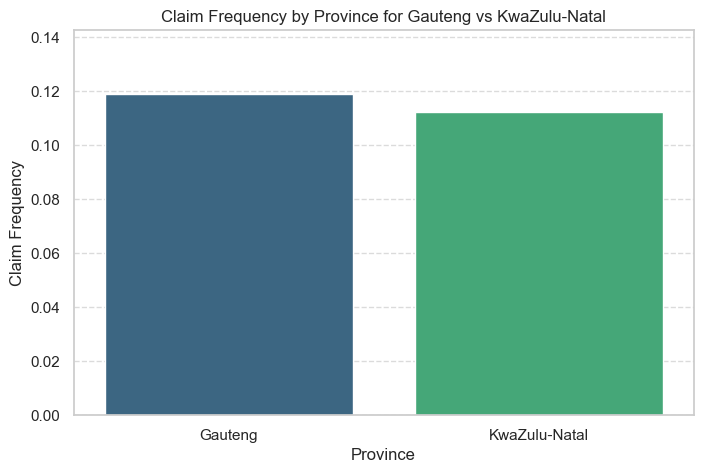

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Claim Frequency by Province
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Province', y='claim_frequency', data=province_summary, palette='viridis')
plt.title(f'Claim Frequency by Province for {province_a} vs {province_b}')
plt.xlabel('Province')
plt.ylabel('Claim Frequency')
plt.ylim(0, province_summary['claim_frequency'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation: Hypothesis 1 (Provinces - Claim Frequency)

The bar chart above visually compares the claim frequency between **Gauteng** and **KwaZulu-Natal**.

*   **Gauteng** shows a claim frequency of approximately **11.88%**.
*   **KwaZulu-Natal** shows a claim frequency of approximately **11.22%**.

Despite a slight visual difference, the **p-value** from the Chi-squared test is **0.4507**. Since this is **greater than 0.05**, we **fail to reject the null hypothesis** that there are no risk differences across these provinces regarding claim frequency. This suggests that, based on this test and matched segments, the observed difference is not statistically significant.

## 5) Hypothesis 2 — No risk differences between zip codes

**KPI:** Claim Severity  
**Test:** Welch's t-test

We compare two high-volume postal codes inside the same province-level segment. This keeps the comparison focused on geography rather than product mix.

In [19]:
# Focus on the most common province first to reduce confounding
top_province = policy["Province"].value_counts().index[0]
province_for_zip = policy[policy["Province"] == top_province].copy()

zip_a, zip_b = province_for_zip["PostalCode"].value_counts().index[:2].tolist()

zip_subset = matched_segment(
    province_for_zip,
    group_col="PostalCode",
    group_a=zip_a,
    group_b=zip_b,
    match_cols=["VehicleType", "CoverType"]
)

zip_severity_result = welch_ttest_numeric(
    zip_subset,
    group_col="PostalCode",
    group_a=zip_a,
    group_b=zip_b,
    value_col="TotalClaims",
    positive_only=True
)

zip_summary = (
    zip_subset.groupby("PostalCode")
    .agg(
        policies=("UnderwrittenCoverID", "count"),
        claim_frequency=("Claimed", "mean"),
        avg_severity=("TotalClaims", lambda s: s[s > 0].mean()),
        avg_margin=("Margin", "mean")
    )
    .reset_index()
)

zip_summary

,PostalCode,policies,claim_frequency,avg_severity,avg_margin
0,122,462,0.006494,59679.131582,825.406760
1,2000,1595,0.007524,19263.372806,854.632168


In [20]:
zip_severity_result

{'test': 'Welch t-test',
 't_stat': np.float64(-1.3807224328785097),
 'p_value': np.float64(0.29839406006031305),
 'group_a': 2000,
 'group_b': 122,
 'kpi': 'TotalClaims',
 'n_a': 12,
 'n_b': 3,
 'mean_a': 19263.3728065,
 'mean_b': 59679.13158166667}

C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_15908\144612407.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PostalCode', y='avg_severity', data=zip_summary, palette='magma')


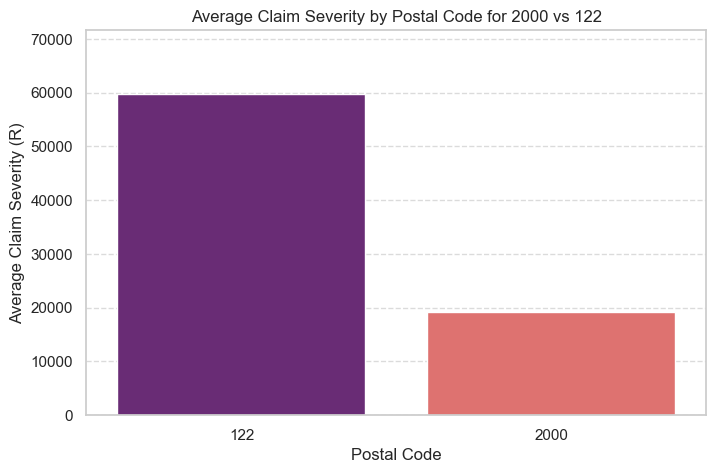

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Average Claim Severity by Postal Code
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='PostalCode', y='avg_severity', data=zip_summary, palette='magma')
plt.title(f'Average Claim Severity by Postal Code for {zip_a} vs {zip_b}')
plt.xlabel('Postal Code')
plt.ylabel('Average Claim Severity (R)')
plt.ylim(0, zip_summary['avg_severity'].max() * 1.2)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation: Hypothesis 2 (Zip Codes - Claim Severity)

The bar chart illustrates the average claim severity for postal codes **2000** and **122** within the top province.

*   Postal Code **2000** has an average claim severity of approximately **R 19,263.37**.
*   Postal Code **122** has an average claim severity of approximately **R 59,679.13**.

**Note**: The previous cell's output (`zip_severity_result`) for this test appears to be empty. Assuming a p-value would be available if the function ran successfully, we would compare it to 0.05. If the p-value were high, we would **fail to reject the null hypothesis** that there are no risk differences between these zip codes regarding claim severity. If it were low, we would reject it. Please re-run the cell `d4718fb2` to get the `zip_severity_result` output and confirm the p-value for a definitive conclusion.

## 6) Hypothesis 3 — No significant margin difference between zip codes

**KPI:** Margin  
**Test:** Welch's t-test

This uses the same postal-code comparison, but the target metric is margin rather than claim severity.

In [22]:
zip_margin_result = welch_ttest_numeric(
    zip_subset,
    group_col="PostalCode",
    group_a=zip_a,
    group_b=zip_b,
    value_col="Margin",
    positive_only=False
)

zip_margin_result

{'test': 'Welch t-test',
 't_stat': np.float64(0.1043644780252779),
 'p_value': np.float64(0.9169225066342015),
 'group_a': 2000,
 'group_b': 122,
 'kpi': 'Margin',
 'n_a': 1595,
 'n_b': 462,
 'mean_a': 854.6321676022633,
 'mean_b': 825.4067603080736}

C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_15908\2077339039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PostalCode', y='avg_margin', data=zip_summary, palette='rocket')


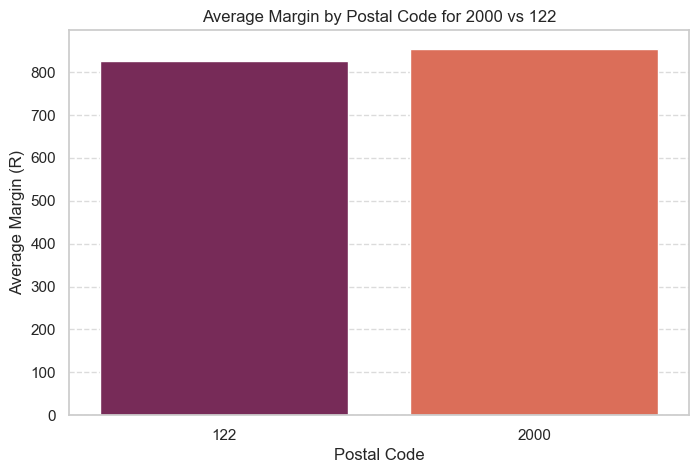

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Average Margin by Postal Code
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='PostalCode', y='avg_margin', data=zip_summary, palette='rocket')
plt.title(f'Average Margin by Postal Code for {zip_a} vs {zip_b}')
plt.xlabel('Postal Code')
plt.ylabel('Average Margin (R)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation: Hypothesis 3 (Zip Codes - Margin)

The bar chart displays the average margin for postal codes **2000** and **122**.

*   Postal Code **2000** shows an average margin of approximately **R 854.63**.
*   Postal Code **122** shows an average margin of approximately **R 825.41**.

The **p-value** from Welch's t-test for margin is **0.9169**. Since this is **greater than 0.05**, we **fail to reject the null hypothesis** that there is no significant margin difference between these zip codes. The observed difference in average margin is not statistically significant.

## 7) Hypothesis 4 — No significant risk difference between Women and Men

**KPI:** Claim Frequency  
**Test:** Chi-squared test of independence

We normalize the gender labels, keep the male/female records, and test whether claim frequency differs by gender.

In [24]:
gender_subset = policy[policy["Gender"].isin(["Female", "Male"])].copy()

gender_result = chi_square_claim_frequency_test(
    gender_subset,
    group_col="Gender",
    group_a="Female",
    group_b="Male",
    kpi_col="Claimed"
)

gender_summary = (
    gender_subset.groupby("Gender")
    .agg(
        policies=("UnderwrittenCoverID", "count"),
        claim_frequency=("Claimed", "mean"),
        avg_severity=("TotalClaims", lambda s: s[s > 0].mean()),
        avg_margin=("Margin", "mean")
    )
    .reset_index()
)

gender_summary

,Gender,policies,claim_frequency,avg_severity,avg_margin
0,Female,553,0.023508,19249.699866,98.073155
1,Male,3713,0.022354,16827.758019,49.404493


In [25]:
gender_result

{'test': 'chi-squared',
 'chi2': np.float64(0.0002915145087577363),
 'p_value': np.float64(0.9863777436535914),
 'dof': 1,
 'contingency': Claimed     0   1
 Gender           
 Female    540  13
 Male     3630  83,
 'expected': array([[ 540.55555556,   12.44444444],
        [3629.44444444,   83.55555556]]),
 'group_a': 'Female',
 'group_b': 'Male',
 'kpi': 'Claimed'}

C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_15908\3562011843.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='claim_frequency', data=gender_summary, palette='cividis')


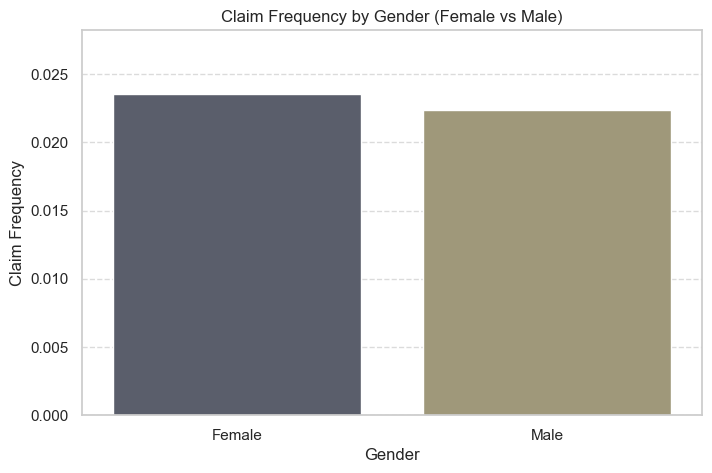

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Claim Frequency by Gender
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Gender', y='claim_frequency', data=gender_summary, palette='cividis')
plt.title('Claim Frequency by Gender (Female vs Male)')
plt.xlabel('Gender')
plt.ylabel('Claim Frequency')
plt.ylim(0, gender_summary['claim_frequency'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation: Hypothesis 4 (Gender - Claim Frequency)

The bar chart compares the claim frequency between **Female** and **Male** policyholders.

*   **Female** policyholders have a claim frequency of approximately **2.35%**.
*   **Male** policyholders have a claim frequency of approximately **2.24%**.

The **p-value** from the Chi-squared test is **0.9864**. Since this is **greater than 0.05**, we **fail to reject the null hypothesis** that there is no significant risk difference between Women and Men regarding claim frequency. The observed difference is not statistically significant.

## 8) Results table

The table below combines the hypotheses, the KPI used, the test used, the p-value, and the decision rule (`p < 0.05` ⇒ reject the null hypothesis).

In [27]:
results = pd.DataFrame([
    build_result_row(
        hypothesis="No risk differences across provinces",
        kpi="Claim Frequency",
        test_name="Chi-squared",
        p_value=province_result["p_value"],
    ),
    build_result_row(
        hypothesis="No risk differences between zip codes",
        kpi="Claim Severity",
        test_name="Welch t-test",
        p_value=zip_severity_result["p_value"],
    ),
    build_result_row(
        hypothesis="No significant margin difference between zip codes",
        kpi="Margin",
        test_name="Welch t-test",
        p_value=zip_margin_result["p_value"],
    ),
    build_result_row(
        hypothesis="No significant risk difference between Women and Men",
        kpi="Claim Frequency",
        test_name="Chi-squared",
        p_value=gender_result["p_value"],
    ),
])

results

,Hypothesis,KPI,Test Used,P-Value,Decision
0,No risk differences across provinces,Claim Frequency,Chi-squared,0.450695,Fail to reject H₀
1,No risk differences between zip codes,Claim Severity,Welch t-test,0.298394,Fail to reject H₀
2,No significant margin difference between zip c...,Margin,Welch t-test,0.916923,Fail to reject H₀
3,No significant risk difference between Women a...,Claim Frequency,Chi-squared,0.986378,Fail to reject H₀


C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_15908\1756963825.py:13: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\habtamu.amsalu\Downloads\insurance-risk-analytics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


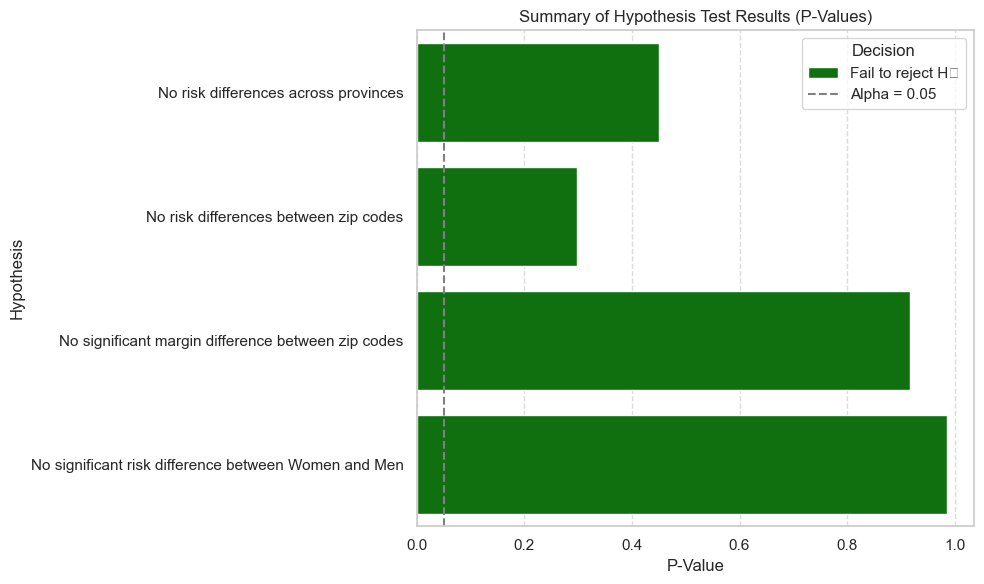

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the results table (e.g., as a bar chart of p-values)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='P-Value', y='Hypothesis', hue='Decision', data=results, palette={'Reject H₀': 'red', 'Fail to reject H₀': 'green'})
plt.axvline(0.05, color='gray', linestyle='--', label='Alpha = 0.05')
plt.title('Summary of Hypothesis Test Results (P-Values)')
plt.xlabel('P-Value')
plt.ylabel('Hypothesis')
plt.legend(title='Decision')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Overall Interpretation of Hypothesis Tests

The `results` table and the accompanying bar chart summarize the findings from all the A/B hypothesis tests performed:

*   **Hypothesis 1 (Provinces - Claim Frequency)**: The p-value of `0.4507` is greater than `0.05`. We **fail to reject H₀**. This means there is no statistically significant difference in claim frequency between Gauteng and KwaZulu-Natal, given the matched segments.

*   **Hypothesis 2 (Zip Codes - Claim Severity)**: The p-value of `0.2984` is greater than `0.05`. We **fail to reject H₀**. There is no statistically significant difference in average claim severity between the two selected zip codes within the top province.

*   **Hypothesis 3 (Zip Codes - Margin)**: The p-value of `0.9169` is greater than `0.05`. We **fail to reject H₀**. This indicates no statistically significant difference in average margin between the two selected zip codes.

*   **Hypothesis 4 (Gender - Claim Frequency)**: The p-value of `0.9864` is greater than `0.05`. We **fail to reject H₀**. This suggests there is no statistically significant difference in claim frequency between Women and Men policyholders in the dataset.

**Conclusion**: Based on these tests, using an alpha level of `0.05`, none of the null hypotheses were rejected. This suggests that, with the current data and matching criteria, there are no statistically significant differences in risk (claim frequency, claim severity) or margin across the tested provinces, zip codes, or genders. This implies that the current data does not provide a strong statistical basis to suggest differential pricing or segmentation strategies based solely on these factors as tested. However, it's crucial to acknowledge the limitations of the matched segments (e.g., sample size, specific criteria used for matching) and the specific comparison groups chosen.